# Flipkart Gridlock Hackathon: Event-Driven Congestion Analysis
## Exploratory Data Analysis & Feature Engineering Notebook

### Project Overview
In rapid-growing urban environments like Bengaluru, event-driven traffic congestion (caused by accidents, water-logging, vehicle breakdowns, construction, etc.) is a major contributor to gridlock. This notebook conducts a comprehensive **Exploratory Data Analysis (EDA)** and **Feature Engineering** process on event log data to:
1. Parse event timelines and locations.
2. Clean and impute missing information (especially event durations).
3. Create meaningful temporal and spatial features.
4. Establish a quantitative **Congestion Proxy Score & Label** to categorize the severity of traffic disruption.
5. Save the structured and processed dataset for downstream machine learning modeling.

---

### Dataset Schema
The analysis focuses on the following core features:
- **`event_type`**: Classification of the event (`planned` vs `unplanned`).
- **`event_cause`**: The root cause of the traffic event (e.g., `vehicle_breakdown`, `accident`, `water_logging`, `pot_holes`, `construction`).
- **`priority`**: Severity class of the ticket (`High` vs `Low`).
- **`requires_road_closure`**: Boolean indicating if the event blocked the entire road/lane.
- **`zone` / `junction`**: Spatial metadata indicating the area or nearest junction of the event.
- **`start_datetime` / `end_datetime`**: The operational start and completion times.
- **`latitude` / `longitude`**: GPS coordinates of the event.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# Professional palette
palette_colors = ["#1D3557", "#457B9D", "#E63946", "#F4A261", "#2A9D8F", "#8D99AE"]
sns.set_palette(palette_colors)

print("Libraries imported and visualization styles configured.")

Libraries imported and visualization styles configured.


In [2]:
# File path
file_path = "Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv"

# Load CSV
df_raw = pd.read_csv(file_path)
print(f"Dataset loaded successfully with {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")

# Select the target columns requested for the EDA
target_cols = [
    'event_type', 'event_cause', 'priority', 'requires_road_closure', 
    'zone', 'junction', 'start_datetime', 'end_datetime', 'latitude', 'longitude'
]

# Keep corridor for extra context in congestion proxy calculation, then filter
extra_cols = ['corridor', 'closed_datetime', 'resolved_datetime']
available_cols = [col for col in target_cols + extra_cols if col in df_raw.columns]

df = df_raw[available_cols].copy()
print(f"Selected columns for processing: {df.columns.tolist()}")
df.head()

Dataset loaded successfully with 8173 rows and 46 columns.
Selected columns for processing: ['event_type', 'event_cause', 'priority', 'requires_road_closure', 'zone', 'junction', 'start_datetime', 'end_datetime', 'latitude', 'longitude', 'corridor', 'closed_datetime', 'resolved_datetime']


,event_type,event_cause,priority,requires_road_closure,zone,junction,start_datetime,end_datetime,latitude,longitude,corridor,closed_datetime,resolved_datetime
0,unplanned,vehicle_breakdown,High,False,NaN,NaN,2024-03-07 17:01:48.111+00,NaN,13.040004,77.518099,Tumkur Road,NaN,NaN
1,unplanned,vehicle_breakdown,High,False,NaN,NaN,2024-01-30 04:07:24.173+00,NaN,12.921876,77.645158,ORR East 1,NaN,2024-01-30 04:17:46.828355+00
2,unplanned,others,Low,False,Central Zone 2,UrvashiJunction,2023-11-11 06:18:03.343+00,NaN,12.955622,77.585708,Non-corridor,2024-01-30 04:56:03.281509+00,NaN
3,unplanned,tree_fall,Low,True,NaN,NaN,2024-03-07 17:56:55.061+00,NaN,13.006147,77.579435,Non-corridor,2024-03-14 07:42:05.54944+00,NaN
4,unplanned,vehicle_breakdown,Low,False,NaN,LalbaghMainGateJunc,2024-01-30 04:56:32.348+00,NaN,12.953980,77.585233,Non-corridor,2024-01-30 05:35:17.338283+00,NaN


## 1. Missing Value Analysis & Handling Strategy
Before training any model or making decisions, we must analyze the distribution of missing values across our feature set and design robust imputation strategies:
- **`priority`**: Extremely low missing rate. We will impute with the mode.
- **`zone` and `junction`**: Highly relevant spatial indicators, but have substantial missingness. We will impute these with `'Unknown'` to preserve their rows, or use spatial grouping.
- **`end_datetime`**: Over 94% of the raw `end_datetime` is missing. However, we have alternate timestamps: `closed_datetime` and `resolved_datetime` which can be used to construct a complete timeline. For rows that are still missing, we will impute the duration using the median duration of the specific `event_cause`.


In [3]:
# 1. Handle missing values for priority
priority_mode = df['priority'].mode()[0]
df['priority'] = df['priority'].fillna(priority_mode)

# 2. Handle missing values for zone and junction
df['zone'] = df['zone'].fillna('Unknown')
df['junction'] = df['junction'].fillna('Unknown')

# 3. Standardize requires_road_closure to Boolean
df['requires_road_closure'] = df['requires_road_closure'].astype(str).str.upper() == 'TRUE'

print("Imputed missing values for categorical features:")
print(f"- Missing priority filled with mode: '{priority_mode}'")
print("- Missing zone filled with: 'Unknown'")
print("- Missing junction filled with: 'Unknown'")
print("- Standardized requires_road_closure to boolean.")

Imputed missing values for categorical features:
- Missing priority filled with mode: 'High'
- Missing zone filled with: 'Unknown'
- Missing junction filled with: 'Unknown'
- Standardized requires_road_closure to boolean.


## 2. Timestamp Parsing & Event Duration Imputation
The key temporal columns represent dates and times. We will parse them, resolve the missingness in `end_datetime` using secondary fields, and then impute the remaining durations:
1. Parse all datetime columns to standard pandas Datetime format in UTC.
2. Define `effective_end_datetime` = `end_datetime` -> `closed_datetime` -> `resolved_datetime`.
3. Compute the initial duration (in minutes) for records with valid end times.
4. Compute the median duration for each `event_cause`.
5. Impute missing durations using the cause-specific median duration.
6. Recompute the missing end datetimes using the imputed durations.


In [4]:
# Convert to datetime
df['start_datetime'] = pd.to_datetime(df['start_datetime'], errors='coerce')
df['end_datetime'] = pd.to_datetime(df['end_datetime'], errors='coerce')
df['closed_datetime'] = pd.to_datetime(df['closed_datetime'], errors='coerce')
df['resolved_datetime'] = pd.to_datetime(df['resolved_datetime'], errors='coerce')

# Create effective end datetime
df['effective_end'] = df['end_datetime']
df['effective_end'] = df['effective_end'].fillna(df['closed_datetime'])
df['effective_end'] = df['effective_end'].fillna(df['resolved_datetime'])

# Calculate initial duration (in minutes) for non-null cases
df['duration_min'] = (df['effective_end'] - df['start_datetime']).dt.total_seconds() / 60.0

# Set negative durations to NaN (logical errors in data entry)
df.loc[df['duration_min'] < 0, 'duration_min'] = np.nan

# Compute median durations per cause
median_durations = df.groupby('event_cause')['duration_min'].median()
global_median_duration = df['duration_min'].median()

print("Median duration (minutes) by Event Cause:")
for cause, med in median_durations.items():
    print(f"  - {cause:20s}: {med:.2f} min" if not np.isnan(med) else f"  - {cause:20s}: NaN (Using global median)")

# Impute missing durations
df['duration_imputed'] = df['duration_min']
for cause in df['event_cause'].unique():
    cause_median = median_durations.get(cause, global_median_duration)
    if np.isnan(cause_median):
        cause_median = global_median_duration
    
    # Fill missing values for this cause
    mask = (df['event_cause'] == cause) & (df['duration_imputed'].isnull())
    df.loc[mask, 'duration_imputed'] = cause_median

# Compute final imputed end datetime
df['end_datetime_final'] = df['start_datetime'] + pd.to_timedelta(df['duration_imputed'], unit='m')

print("\nImputation Summary:")
print(f"- Number of records with original end/closed/resolved time: {df['duration_min'].notnull().sum()}")
print(f"- Number of records imputed: {df['duration_min'].isnull().sum()}")
print(f"- Final missing durations remaining: {df['duration_imputed'].isnull().sum()}")

Median duration (minutes) by Event Cause:
  - Debris              : 86853.32 min
  - Fog / Low Visibility: NaN (Using global median)
  - accident            : 41.70 min
  - congestion          : 71.54 min
  - construction        : 726.55 min
  - debris              : NaN (Using global median)
  - others              : 416.14 min
  - pot_holes           : 12122.20 min
  - procession          : 73.68 min
  - protest             : 10.66 min
  - public_event        : 234.17 min
  - road_conditions     : 9236.32 min
  - test_demo           : 1.82 min
  - tree_fall           : 634.95 min
  - vehicle_breakdown   : 41.10 min
  - vip_movement        : 8683.83 min
  - water_logging       : 3688.33 min

Imputation Summary:
- Number of records with original end/closed/resolved time: 3497
- Number of records imputed: 4676
- Final missing durations remaining: 0


## 3. Feature Engineering
With cleaned timestamps and locations, we extract features to capture temporal and structural patterns:
- **`hour`**: The hour of the day when the event started (0 to 23).
- **`weekday`**: Day of the week (0 = Monday, 6 = Sunday).
- **`is_weekend`**: Indicator flag (1 if Saturday/Sunday, else 0).
- **`time_of_day`**: Categorized into `morning_peak` (08:00 - 11:00), `midday` (11:00 - 17:00), `evening_peak` (17:00 - 20:00), and `night` (20:00 - 08:00).
- **`log_duration`**: Log10-transformed duration to normalize the extreme positive skewness of event durations.


In [5]:
# Hour and Weekday
df['hour'] = df['start_datetime'].dt.hour
df['weekday'] = df['start_datetime'].dt.weekday
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Time of day categories
def get_time_of_day(hour):
    if 8 <= hour < 11:
        return 'morning_peak'
    elif 17 <= hour < 20:
        return 'evening_peak'
    elif 11 <= hour < 17:
        return 'midday'
    else:
        return 'night'

df['time_of_day'] = df['hour'].apply(get_time_of_day)

# Log duration (adding 1 to avoid log(0))
df['log_duration'] = np.log10(df['duration_imputed'] + 1)

print("Generated features:")
print(df[['start_datetime', 'hour', 'weekday', 'is_weekend', 'time_of_day', 'duration_imputed', 'log_duration']].head())

Generated features:
                    start_datetime  hour  weekday  is_weekend   time_of_day  \
0 2024-03-07 17:01:48.111000+00:00  17.0      3.0           0  evening_peak   
1 2024-01-30 04:07:24.173000+00:00   4.0      1.0           0         night   
2 2023-11-11 06:18:03.343000+00:00   6.0      5.0           1         night   
3 2024-03-07 17:56:55.061000+00:00  17.0      3.0           0  evening_peak   
4 2024-01-30 04:56:32.348000+00:00   4.0      1.0           0         night   

   duration_imputed  log_duration  
0         41.102746      1.624310  
1         10.377589      1.056050  
2     115117.998975      5.061147  
3       9465.174807      3.976175  
4         38.749838      1.599335  


## 4. Congestion Proxy Label Creation
To evaluate the impact of different traffic events, we construct a quantitative **Congestion Index** and group it into categorical **Congestion Proxy Labels** (`Low`, `Medium`, `High`).

The index is constructed based on domain-specific weightings of factors known to exacerbate gridlock:
1. **Event Cause Severity** (Base Score: 0 to 10):
   - `accident`: 10
   - `water_logging`, `congestion`: 9
   - `tree_fall`: 8
   - `vehicle_breakdown`: 7
   - `road_conditions`: 6
   - `construction`, `public_event`: 5
   - `others`, `procession`, `protest`: 4
   - All other/unknown causes: 4
2. **Road Blockage (requires_road_closure)**:
   - If `True`, adds **+5 points** to the score.
3. **Priority Class**:
   - `High` priority adds **+3 points**; `Low` adds **+1 point**.
4. **Time of Day (Peak Traffic Coincidence)**:
   - If starting during peak hours (`morning_peak` or `evening_peak`), adds **+3 points**.
   - If starting during `midday` (high baseline traffic), adds **+1.5 points**.
   - Night events add **+0 points**.
5. **Corridor Class**:
   - If the event occurs on a designated corridor (i.e. `corridor` is not null and not `'Non-corridor'`), adds **+2 points**.

### Congestion Label Bins:
- **Low**: Score < 10 (Minor incidents, off-peak, or low-priority areas)
- **Medium**: 10 <= Score < 15 (Standard breakdowns or peak events on secondary roads)
- **High**: Score >= 15 (Major accidents, road closures, or water-logging during peak hours on primary corridors)


In [6]:
# 1. Base cause severity map
cause_severity = {
    'accident': 10,
    'water_logging': 9,
    'congestion': 9,
    'tree_fall': 8,
    'vehicle_breakdown': 7,
    'road_conditions': 6,
    'construction': 5,
    'public_event': 5,
    'others': 4,
    'procession': 4,
    'protest': 4
}

# 2. Compute Congestion Score
def calculate_congestion_score(row):
    # Base Cause Score
    score = cause_severity.get(row['event_cause'], 4)
    
    # Road closure impact
    if row['requires_road_closure']:
        score += 5
        
    # Priority impact
    if row['priority'] == 'High':
        score += 3
    else:
        score += 1
        
    # Time of Day impact
    if row['time_of_day'] in ['morning_peak', 'evening_peak']:
        score += 3
    elif row['time_of_day'] == 'midday':
        score += 1.5
        
    # Corridor impact
    if 'corridor' in row.index and pd.notnull(row['corridor']) and row['corridor'] != 'Non-corridor':
        score += 2
        
    return score

df['congestion_score'] = df.apply(calculate_congestion_score, axis=1)

# 3. Bin into Low, Medium, High labels
def get_congestion_label(score):
    if score < 10:
        return 'Low'
    elif score < 15:
        return 'Medium'
    else:
        return 'High'

df['congestion_proxy_label'] = df['congestion_score'].apply(get_congestion_label)

# Set category ordering
df['congestion_proxy_label'] = pd.Categorical(df['congestion_proxy_label'], categories=['Low', 'Medium', 'High'], ordered=True)

print("Congestion Score statistics:")
print(df['congestion_score'].describe())

print("\nCongestion Proxy Label counts:")
print(df['congestion_proxy_label'].value_counts())

Congestion Score statistics:
count    8173.000000
mean       11.101493
std         2.967675
min         5.000000
25%         9.000000
50%        12.000000
75%        12.000000
max        23.000000
Name: congestion_score, dtype: float64

Congestion Proxy Label counts:
congestion_proxy_label
Medium    4362
Low       2631
High      1180
Name: count, dtype: int64


## 5. Visualizations & Insights
In this section, we analyze the distribution of events across different categorical, temporal, spatial, and congestion dimensions to gain insights for traffic management.


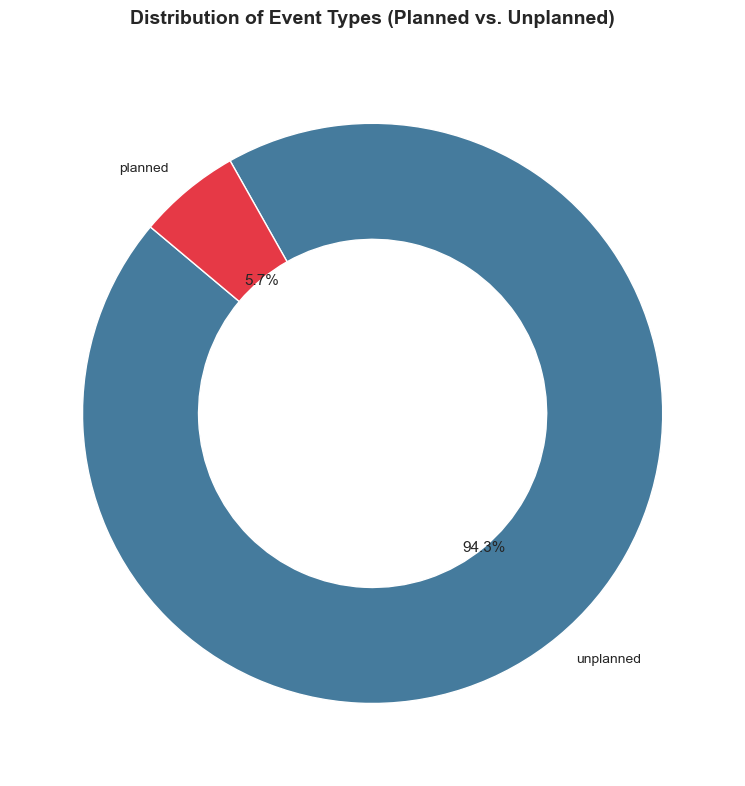

In [7]:
plt.figure(figsize=(8, 8))
event_counts = df['event_type'].value_counts()
plt.pie(event_counts, labels=event_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=['#457B9D', '#E63946'], wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Distribution of Event Types (Planned vs. Unplanned)', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('visualizations_event_types.png', dpi=300)
plt.show()

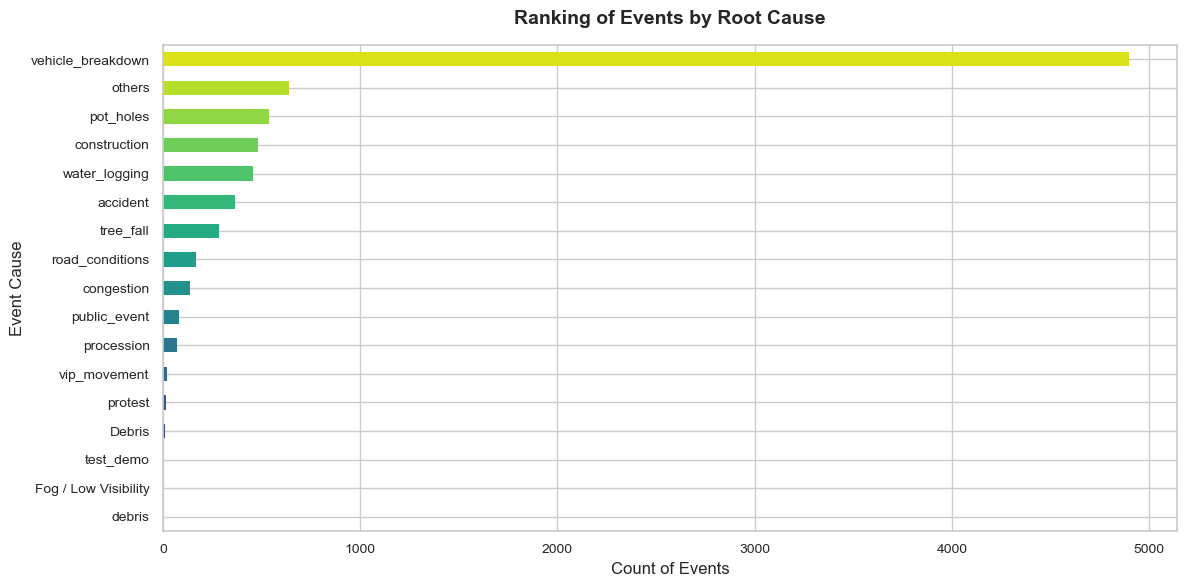

In [8]:
plt.figure(figsize=(12, 6))
cause_counts = df['event_cause'].value_counts().sort_values(ascending=True)
colors = sns.color_palette("viridis", len(cause_counts))
cause_counts.plot(kind='barh', color=colors, edgecolor='none')
plt.title('Ranking of Events by Root Cause', fontsize=14, weight='bold', pad=15)
plt.xlabel('Count of Events')
plt.ylabel('Event Cause')
plt.tight_layout()
plt.savefig('visualizations_event_causes.png', dpi=300)
plt.show()

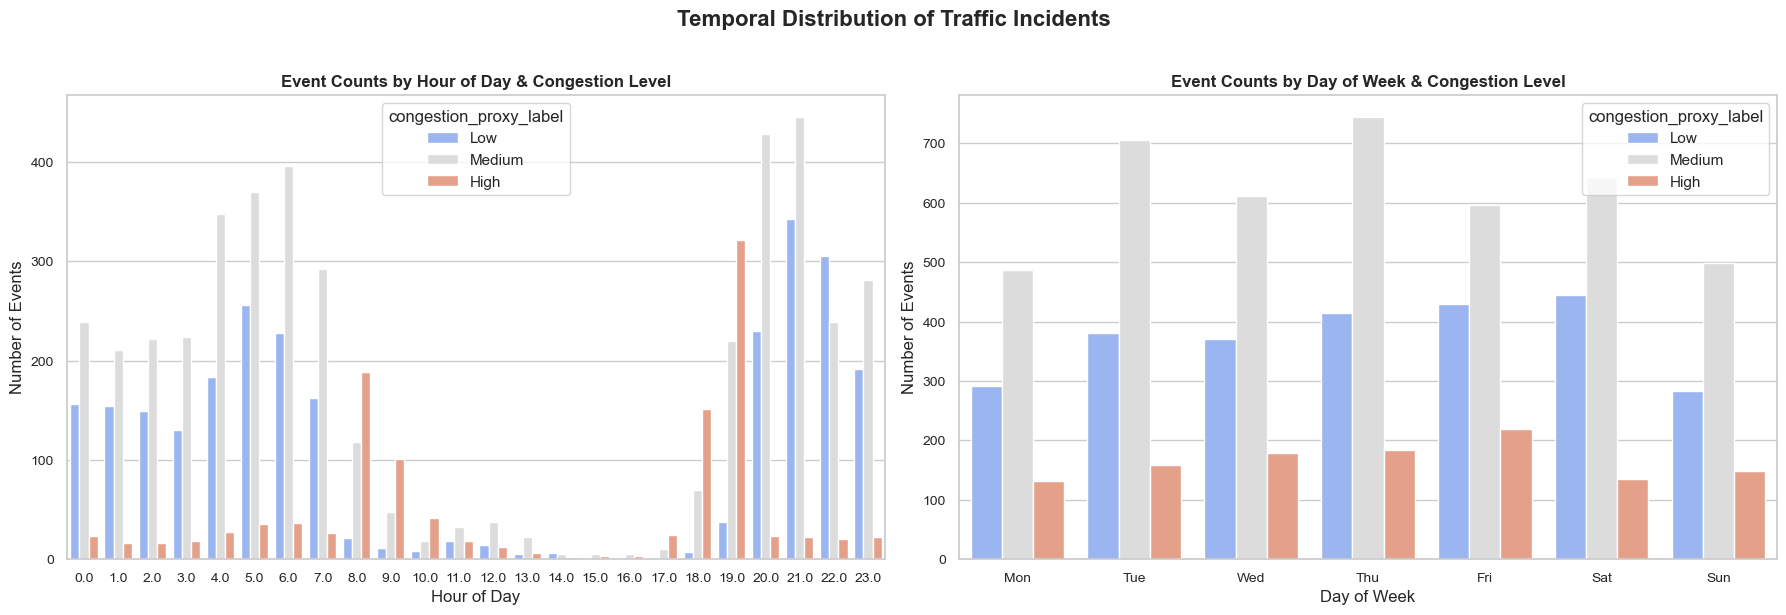

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Hourly Distribution
sns.countplot(data=df, x='hour', hue='congestion_proxy_label', ax=axes[0], palette='coolwarm')
axes[0].set_title('Event Counts by Hour of Day & Congestion Level', fontsize=12, weight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Events')

# Weekday Distribution
weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.countplot(data=df, x='weekday', hue='congestion_proxy_label', ax=axes[1], palette='coolwarm')
axes[1].set_title('Event Counts by Day of Week & Congestion Level', fontsize=12, weight='bold')
axes[1].set_xticklabels(weekday_labels)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Events')

plt.suptitle('Temporal Distribution of Traffic Incidents', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visualizations_temporal_patterns.png', dpi=300)
plt.show()

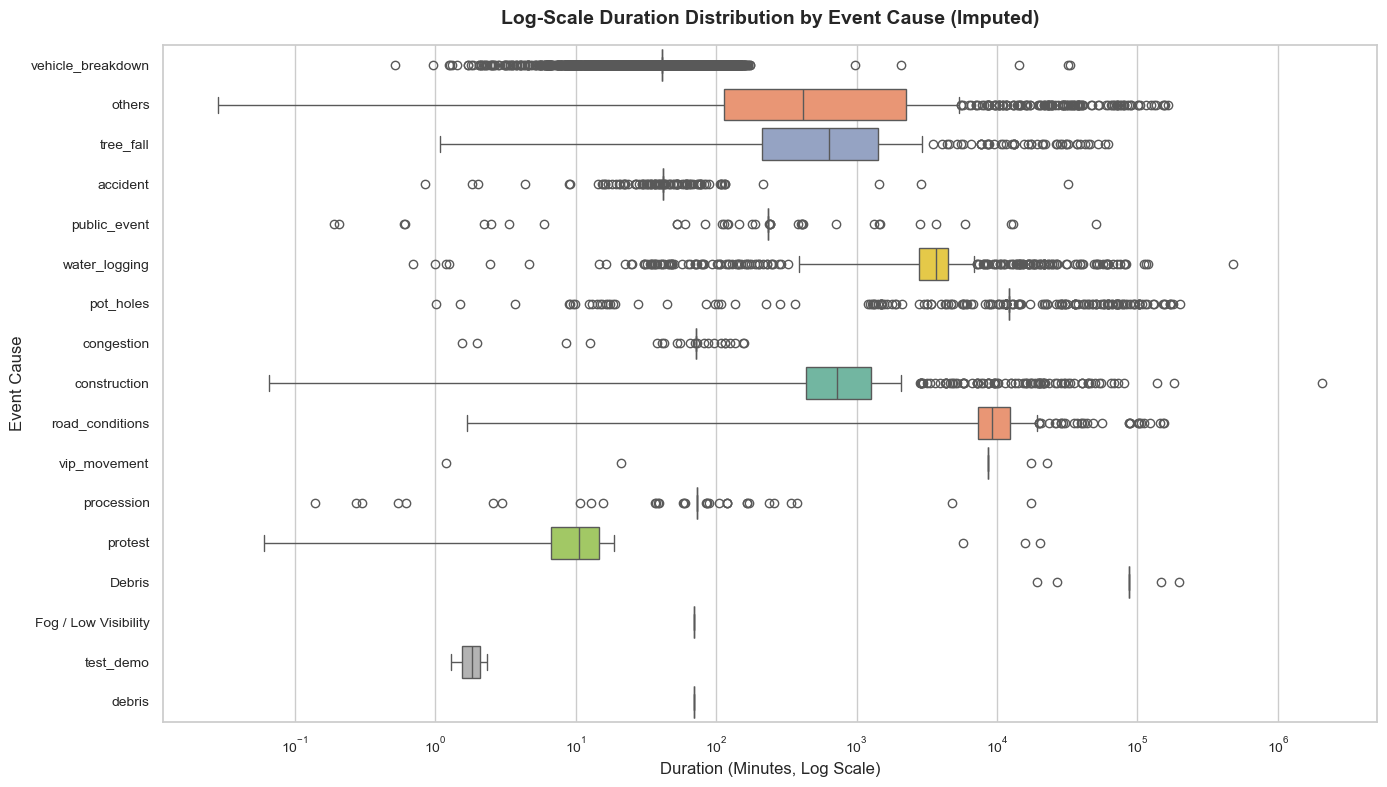

In [10]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, y='event_cause', x='duration_imputed', palette='Set2')
plt.xscale('log')
plt.title('Log-Scale Duration Distribution by Event Cause (Imputed)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Duration (Minutes, Log Scale)')
plt.ylabel('Event Cause')
plt.tight_layout()
plt.savefig('visualizations_duration_analysis.png', dpi=300)
plt.show()

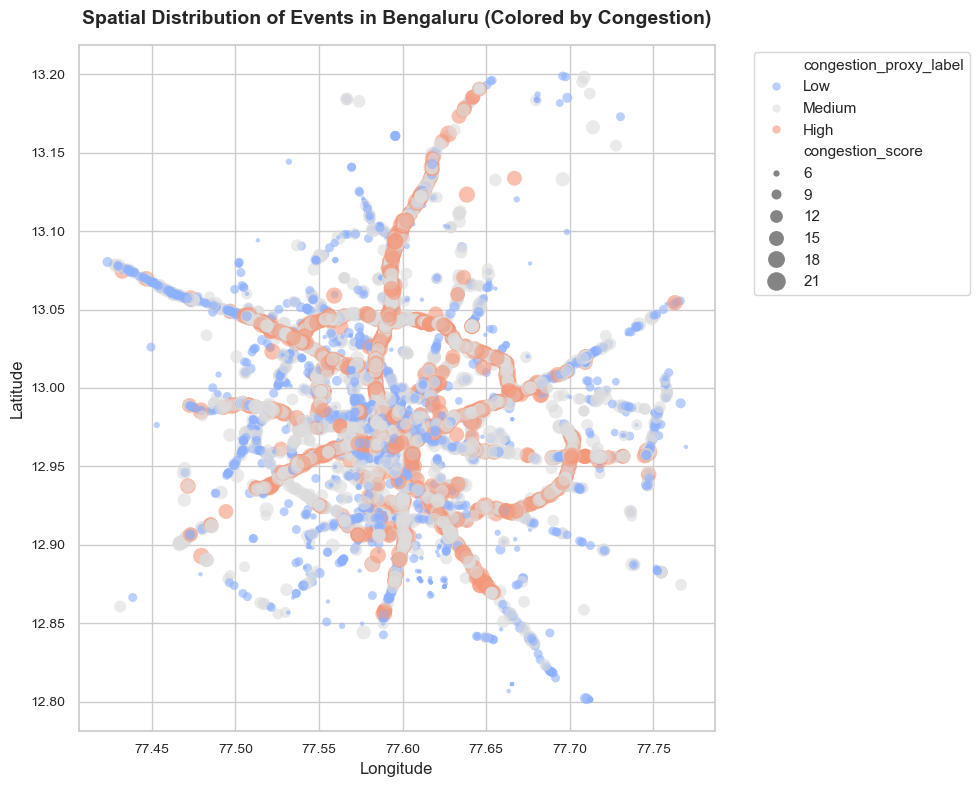

In [11]:
plt.figure(figsize=(10, 8))

# Filter extreme lat/long outliers to focus on Bengaluru central coordinates
lat_min, lat_max = 12.8, 13.2
lon_min, lon_max = 77.4, 77.8

mask = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max) &        (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)
df_spatial = df[mask]

sns.scatterplot(
    data=df_spatial, 
    x='longitude', 
    y='latitude', 
    hue='congestion_proxy_label', 
    alpha=0.6, 
    palette='coolwarm',
    size='congestion_score',
    sizes=(10, 200),
    edgecolor='none'
)

plt.title('Spatial Distribution of Events in Bengaluru (Colored by Congestion)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('visualizations_spatial_distribution.png', dpi=300)
plt.show()

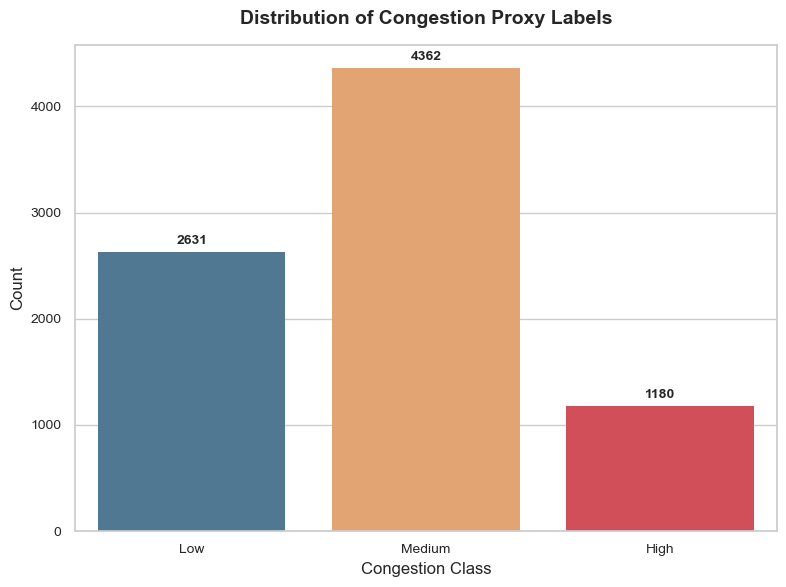

In [12]:
plt.figure(figsize=(8, 6))
colors = ["#457B9D", "#F4A261", "#E63946"]  # Low, Medium, High
ax = sns.countplot(data=df, x='congestion_proxy_label', palette=colors, edgecolor='none')
plt.title('Distribution of Congestion Proxy Labels', fontsize=14, weight='bold', pad=15)
plt.xlabel('Congestion Class')
plt.ylabel('Count')

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('visualizations_congestion_distribution.png', dpi=300)
plt.show()

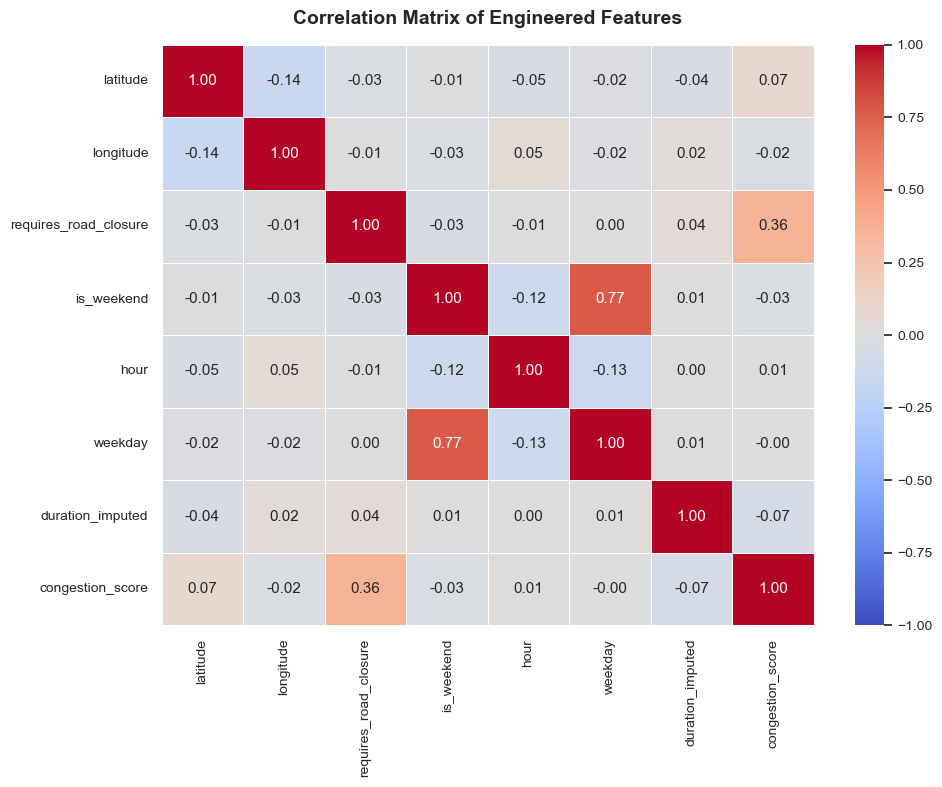

In [13]:
plt.figure(figsize=(10, 8))

# Select numerical/boolean columns for correlation
corr_cols = ['latitude', 'longitude', 'requires_road_closure', 'is_weekend', 'hour', 'weekday', 'duration_imputed', 'congestion_score']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Engineered Features', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.savefig('visualizations_correlation_matrix.png', dpi=300)
plt.show()

## 6. Saving Processed Data
We now filter our columns to include only the specified dataset fields along with the engineered features, and export the processed dataset to a CSV file.


In [14]:
# List final columns to export
final_cols = [
    'event_type', 'event_cause', 'priority', 'requires_road_closure', 
    'zone', 'junction', 'start_datetime', 'end_datetime_final', 'latitude', 'longitude',
    'hour', 'weekday', 'is_weekend', 'time_of_day', 'duration_imputed', 
    'congestion_score', 'congestion_proxy_label'
]

# Rename columns to fit user specs
df_export = df[final_cols].rename(columns={'end_datetime_final': 'end_datetime', 'duration_imputed': 'duration_minutes'})

# Save to CSV
output_filename = "processed_congestion_data.csv"
df_export.to_csv(output_filename, index=False)
print(f"Processed dataset saved successfully to '{output_filename}'.")
print(f"Final dataset shape: {df_export.shape}")

print("\nSample records from the processed export:")
df_export.head()

Processed dataset saved successfully to 'processed_congestion_data.csv'.
Final dataset shape: (8173, 17)

Sample records from the processed export:


,event_type,event_cause,priority,requires_road_closure,zone,junction,start_datetime,end_datetime,latitude,longitude,hour,weekday,is_weekend,time_of_day,duration_minutes,congestion_score,congestion_proxy_label
0,unplanned,vehicle_breakdown,High,False,Unknown,Unknown,2024-03-07 17:01:48.111000+00:00,2024-03-07 17:42:54.275789502+00:00,13.040004,77.518099,17.0,3.0,0,evening_peak,41.102746,15.0,High
1,unplanned,vehicle_breakdown,High,False,Unknown,Unknown,2024-01-30 04:07:24.173000+00:00,2024-01-30 04:17:46.828355+00:00,12.921876,77.645158,4.0,1.0,0,night,10.377589,12.0,Medium
2,unplanned,others,Low,False,Central Zone 2,UrvashiJunction,2023-11-11 06:18:03.343000+00:00,2024-01-30 04:56:03.281509+00:00,12.955622,77.585708,6.0,5.0,1,night,115117.998975,5.0,Low
3,unplanned,tree_fall,Low,True,Unknown,Unknown,2024-03-07 17:56:55.061000+00:00,2024-03-14 07:42:05.549439998+00:00,13.006147,77.579435,17.0,3.0,0,evening_peak,9465.174807,17.0,High
4,unplanned,vehicle_breakdown,Low,False,Unknown,LalbaghMainGateJunc,2024-01-30 04:56:32.348000+00:00,2024-01-30 05:35:17.338283+00:00,12.953980,77.585233,4.0,1.0,0,night,38.749838,8.0,Low
